In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# 1. Define the Model: Takes (x, y) as input, outputs u
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='tanh', input_shape=(2,)),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
@tf.function
def train_step(x_inner, y_inner, x_bnd, y_bnd, u_bnd):
    with tf.GradientTape() as total_tape:
        # --- Physics Loss (Interior Points) ---
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x_inner, y_inner])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x_inner, y_inner])
                # Combine x and y into a single input for the model
                X_in = tf.concat([x_inner, y_inner], axis=1)
                u = model(X_in)
            
            # First derivatives
            u_x = tape1.gradient(u, x_inner)
            u_y = tape1.gradient(u, y_inner)
            
        # Second derivatives
        u_xx = tape2.gradient(u_x, x_inner)
        u_yy = tape2.gradient(u_y, y_inner)
        
        # Laplace Residual: u_xx + u_yy = 0
        loss_pde = tf.reduce_mean(tf.square(u_xx + u_yy))
        # --- Boundary Loss ---
        X_bnd = tf.concat([x_bnd, y_bnd], axis=1)
        u_bnd_pred = model(X_bnd)
        loss_bc = tf.reduce_mean(tf.square(u_bnd_pred - u_bnd))
        total_loss = loss_pde + loss_bc
    grads = total_tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return total_loss

# 2. Data Generation (Collocation Points)
# Interior points
x_in = tf.random.uniform((1000, 1), 0, 1)
y_in = tf.random.uniform((1000, 1), 0, 1)
# Boundary points (e.g., Top edge at y=1 is 100 degrees, others 0)
# This is a simplified example of generating boundary data
x_b = tf.concat([np.random.rand(100,1), np.random.rand(100,1), np.zeros((100,1)), np.ones((100,1))], 0)
y_b = tf.concat([np.ones((100,1)), np.zeros((100,1)), np.random.rand(100,1), np.random.rand(100,1)], 0)
u_b = tf.concat([np.ones((100,1)), np.zeros((100,1)), np.ones((100,1)), np.zeros((100,1))], 0)
x_b, y_b, u_b = tf.cast(x_b, tf.float32), tf.cast(y_b, tf.float32), tf.cast(u_b, tf.float32)
print(x_in.shape, x_b.shape, y_b.shape, u_b.shape)
# 3. Training Loop
for i in range(3000):
    loss = train_step(x_in, y_in, x_b, y_b, u_b)
    if i % 500 == 0:
        print(f"Iteration {i}, Loss: {loss.numpy()}")

(1000, 1) (400, 1) (400, 1) (400, 1)
Iteration 0, Loss: 0.3163686692714691
Iteration 500, Loss: 0.06132838502526283
Iteration 1000, Loss: 0.04467633366584778
Iteration 1500, Loss: 0.02806723676621914
Iteration 2000, Loss: 0.025360286235809326
Iteration 2500, Loss: 0.02279379591345787


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


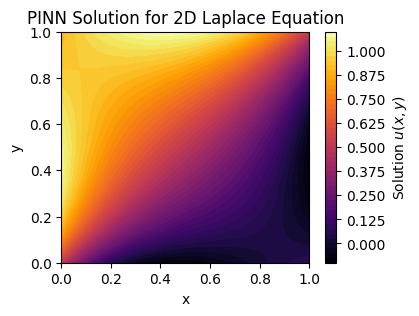

In [10]:
import numpy as np
import matplotlib.pyplot as plt
def visualize_square_solution(model, resolution=100):
    # 1. Create a 100x100 grid of (x, y) coordinates
    x_range = np.linspace(0, 1, resolution)
    y_range = np.linspace(0, 1, resolution)
    X, Y = np.meshgrid(x_range, y_range)
    
    # 2. Flatten the grid to feed it into the model
    # We create an array of shape (resolution*resolution, 2)
    X_flat = X.flatten().reshape(-1, 1)
    Y_flat = Y.flatten().reshape(-1, 1)
    XY_input = np.hstack([X_flat, Y_flat])
    
    # 3. Predict the 'u' values (Temperature/Potential)
    # We cast to float32 to match the model's expected type
    U_flat = model.predict(XY_input.astype('float32'))
    
    # 4. Reshape the predictions back to the 100x100 grid shape
    U = U_flat.reshape(resolution, resolution)
    
    # 5. Plotting
    plt.figure(figsize=(4, 3))
    # 'pcolormesh' or 'contourf' are great for heatmaps
    cp = plt.contourf(X, Y, U, levels=50, cmap='inferno')
    plt.colorbar(cp, label='Solution $u(x,y)$')
    
    plt.title("PINN Solution for 2D Laplace Equation")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
# Assuming your 'model' is already trained from the previous step:
visualize_square_solution(model,200)